In [1]:
import os
import glob
import pandas as pd
import numpy as np
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from scipy.stats import pearsonr
from adjustText import adjust_text
from tqdm import tqdm
import time
from collections import Counter
from matplotlib.patches import Patch
from scipy.spatial.distance import cdist
import textwrap
import re
import scipy
from scanpy.tools._utils import get_init_pos_from_paga 
import warnings
import networkx as nx

from scipy.stats import zscore
from matplotlib.colors import LinearSegmentedColormap
from scipy.cluster.hierarchy import linkage, fcluster
import matplotlib.patheffects as pe
from collections import defaultdict

import rmm
import cupy
import cudf
import cupy as cp
import cvxpy as cpv
from sklearn.manifold import MDS
from cuml.metrics import pairwise_distances
from cuml.metrics import nan_euclidean_distances
from rmm.allocators.cupy import rmm_cupy_allocator
from sklearn.feature_extraction.text import CountVectorizer
from cuml.linear_model import ElasticNet
import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi
from cuml.manifold.umap import simplicial_set_embedding
from scanpy.tools._utils import get_init_pos_from_paga 
from cuml.manifold.umap import find_ab_params

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

# Load data

In [19]:
start = time.perf_counter()

path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_merged_gene_data.h5ad"

adata = sc.read_h5ad(path)

sc.logging.print_memory_usage() 
print(f"Total time: {time.perf_counter() - start:.2f} seconds")


### Filter for control cells
adata = adata[adata.obs['dataset'] == 'Control']
adata

Memory usage: current 7.76 GB, difference +4.72 GB
Total time: 4.97 seconds


View of AnnData object with n_obs × n_vars = 6960 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'leiden', 'cluster_str', 'S_score', 'G2M_score', 'phase'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highl

# Score cell cycle genes

In [20]:
%%time
regev_genes = [x.strip() for x in open('../../resources/regev_lab_cell_cycle_genes.txt')]
s_genes = regev_genes[:43]
g2m_genes = regev_genes[43:]

sc.tl.score_genes_cell_cycle(
    adata,
    s_genes=s_genes,
    g2m_genes=g2m_genes,
)

adata.obs.head()

/home/jrcwycy/miniconda3/envs/rapids_singlecell/lib/python3.13/site-packages/scanpy/tools/_score_genes.py:165: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[score_name] = pd.Series(


CPU times: user 953 ms, sys: 1.51 s, total: 2.46 s
Wall time: 2.49 s


,MYOD-fb_counts,PRRX1-fb_counts,PRRX1_MYOD-fb_counts,assigned_condition,total_fb_counts,condition_counts_rate,G1-fb_counts,G2M-fb_counts,S-fb_counts,dataset,...,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,outlier,mt_outlier,leiden,cluster_str,S_score,G2M_score,phase
AAACCAAAGGGTAGCA_control,NaN,NaN,NaN,G2M,2.0,1.00,0.0,2.0,0.0,Control,...,3628.0,8.196712,17.779085,False,False,3,C4,0.102025,0.515162,G2M
AAACCAAAGTAAGGGT_control,NaN,NaN,NaN,G1,2.0,1.00,2.0,0.0,0.0,Control,...,2108.0,7.653969,20.748032,False,False,4,C5,-0.201778,-0.295685,G1
AAACCATTCAGGTAGG_control,NaN,NaN,NaN,G1,2.0,1.00,2.0,0.0,0.0,Control,...,3186.0,8.066835,15.895031,False,False,3,C4,0.077670,0.607458,G2M
AAACCATTCCAGCCCT_control,NaN,NaN,NaN,S,4.0,1.00,0.0,0.0,4.0,Control,...,3506.0,8.162517,26.444412,False,False,4,C5,-0.208720,-0.279503,G1
AAACCATTCGTGACCG_control,NaN,NaN,NaN,G1,4.0,0.75,3.0,0.0,1.0,Control,...,2087.0,7.643962,18.075523,False,False,4,C5,-0.257642,-0.201526,G1


# Gene filtering

In [21]:
adata.X = adata.layers['raw_counts'].copy()

X = adata.X

if sp.issparse(X):
    # replace NaNs in the nonzero entries
    X.data = np.nan_to_num(X.data, nan=0)
    adata.X = X
else:
    # dense array
    adata.X = np.nan_to_num(X, nan=0)

# adata.X = adata.X.astype(int)
print(f"{adata.X.shape=}")
print(f"{type(adata.X)=}")

adata

adata.X.shape=(6960, 25126)
type(adata.X)=<class 'scipy.sparse._csr.csr_matrix'>


AnnData object with n_obs × n_vars = 6960 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'leiden', 'cluster_str', 'S_score', 'G2M_score', 'phase'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variab

In [22]:
gdf = adata.var[['gene_type']].copy()
gdf = gdf.reset_index(names='names')

protein_coding = gdf[gdf['gene_type'] == 'protein_coding']['names'].unique()
print(len(protein_coding))

15822


In [23]:
rsc.get.anndata_to_GPU(adata)

adata.var['filter_pass'] = True # set the gene filter

# pt genes only
adata.var['filter_pass'] = np.where(~adata.var.index.isin(protein_coding), False, adata.var['filter_pass'])

# # disallow GO cell cycle genes
# fpath = "../../resources/human_cell_cycle_genes.csv"
# cdf = pd.read_csv(fpath)
# adata.var['filter_pass'] = np.where(adata.var.index.isin(cdf['gene_name'].unique()), False, adata.var['filter_pass'])

# # disallow Regev cell cycle genes
# fpath = "../../resources/regev_lab_cell_cycle_genes.txt"
# genes = [x.strip() for x in open(fpath)]
# adata.var['filter_pass'] = np.where(adata.var.index.isin(genes), False, adata.var['filter_pass'])

# disallow mitochondrial and ribosomal genes
adata.var['filter_pass'] = np.where(adata.var.index.str.startswith('MT'), False, adata.var['filter_pass'])
adata.var['filter_pass'] = np.where(adata.var.index.str.startswith('RP'), False, adata.var['filter_pass'])

rsc.get.anndata_to_CPU(adata)

print(adata.var['filter_pass'].value_counts().to_string())

filter_pass
True     15599
False     9527


/home/jrcwycy/miniconda3/envs/rapids_singlecell/lib/python3.13/site-packages/rapids_singlecell/preprocessing/_hvg.py:534: UserWarning: `flavor='seurat_v3'` expects `n_top_genes`  to be defined, defaulting to 2000 HVGs
  warnings.warn(


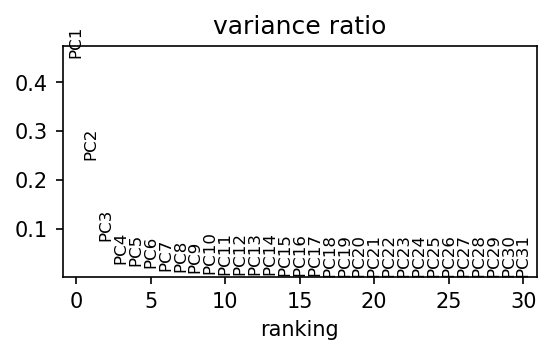

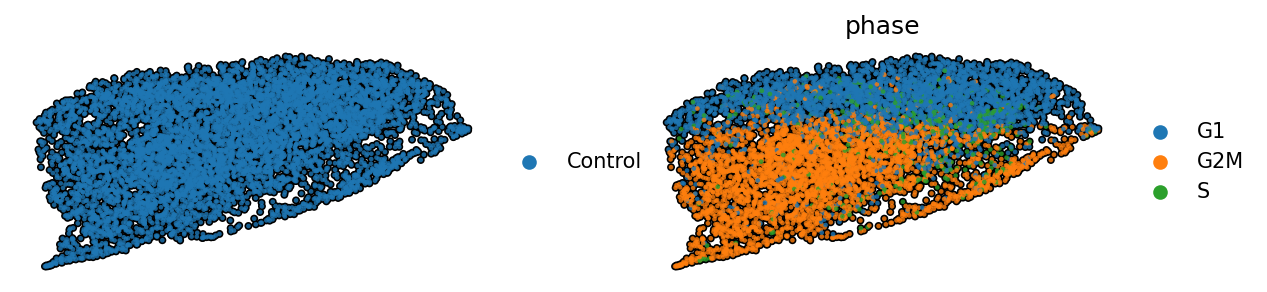

In [24]:
rsc.get.anndata_to_GPU(adata)

rsc.pp.highly_variable_genes(
    adata,
    flavor="seurat_v3",
)

rsc.pp.pca(adata)

rsc.pp.neighbors(
    adata, 
    n_neighbors=15,
)

rsc.tl.umap(
    adata,
)

rsc.get.anndata_to_CPU(adata)

sc.pl.pca_variance_ratio(adata)

sc.pl.umap(
    adata,
    color=['pooled_condition', 'phase'],
    size=20,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False, 
    alpha=0.8,
    title="",
)

# SCVI

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [MIG-53247e0a-def4-58dc-9b4c-a5e330fb34ed]
SLURM auto-requeueing enabled. Setting signal handlers.


Training:   0%|          | 0/500 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 5 records. Best score: 1836.053. Signaling Trainer to stop.


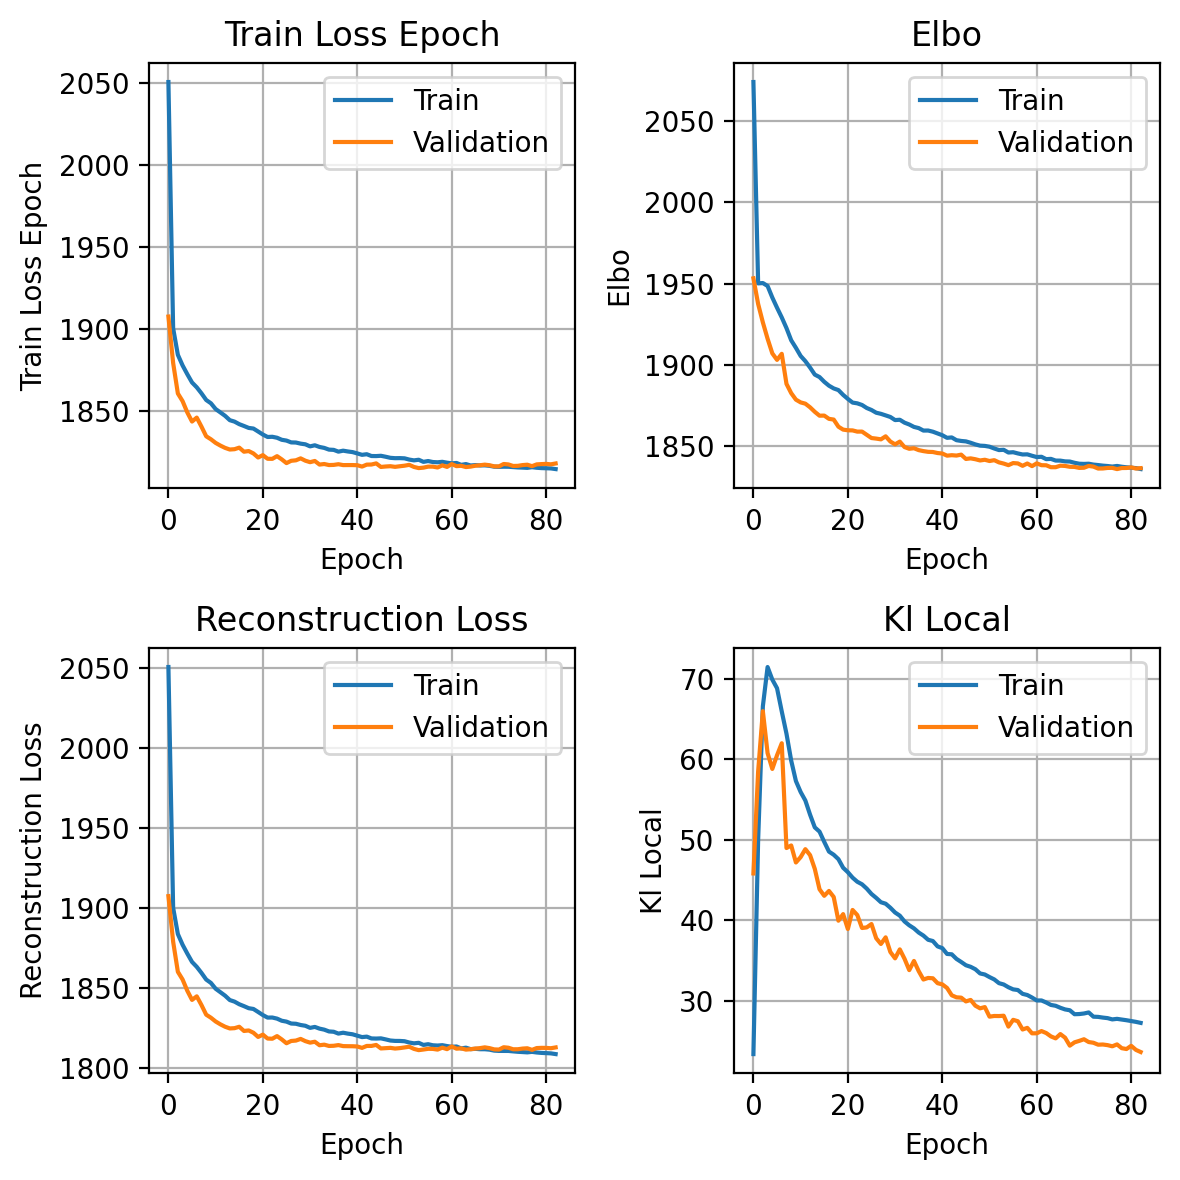

CPU times: user 3min 3s, sys: 1.86 s, total: 3min 5s
Wall time: 3min 7s


In [38]:
%%time
# batch_key = "dataset"

bdata = adata.copy()

bdata = bdata[:, bdata.var['filter_pass']].copy()

rsc.get.anndata_to_GPU(bdata)
rsc.pp.highly_variable_genes(
    bdata,
    flavor="seurat_v3",
    n_top_genes=2500, # If only doing embedding, can lower this; if wanting to quantify gene expression, need to increase this number
    # batch_key=batch_key,
)

bdata = bdata[:, bdata.var['highly_variable']].copy()
rsc.get.anndata_to_CPU(bdata)

# scvi
scvi.model.SCVI.setup_anndata(
    bdata, 
    # batch_key=batch_key,
    continuous_covariate_keys=['S_score', 'G2M_score'],
)

model = scvi.model.SCVI(
    bdata,
    n_hidden=128,
    n_latent=20, # size of latent space we're learning; too small might not be able to capture biological differences; too large might be overfitting (good between 10-36; aim for 10-15 for MYOD data)
    n_layers=2, 
    dropout_rate=0.25, # really impacts curves below
    dispersion='gene-cell',
    gene_likelihood='zinb',
)

model.train(
    max_epochs=500,
    accelerator='gpu',
    early_stopping_patience=5, # go until we reach 5 consecutive steps without learning anything new
    early_stopping=True,
    batch_size=25,
    train_size=0.9,
    plan_kwargs={"lr": 1e-3}, # learning rate -- small is careful/cautiously forward; large is wrecklessly forward, can get stuck in local minimum (good values e-2 to e-6)
)

history = model.history

metrics = [
    ("train_loss_epoch", "validation_loss"),
    ("elbo_train", "elbo_validation"),
    ("reconstruction_loss_train", "reconstruction_loss_validation"),
    ("kl_local_train", "kl_local_validation"),
]

plt.rcParams['figure.dpi'] = 200
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
axes = axes.flatten()

for i, (train_key, val_key) in enumerate(metrics):
    ax = axes[i]
    train_df = history[train_key]
    val_df = history[val_key]

    ax.plot(train_df.index, train_df[train_key], label='Train')
    ax.plot(val_df.index, val_df[val_key], label='Validation')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(train_key.replace('_train', '').replace('_', ' ').title())
    ax.set_title(train_key.replace('_train', '').replace('_', ' ').title())
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

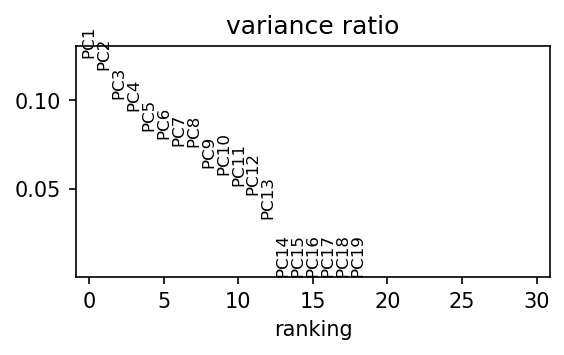

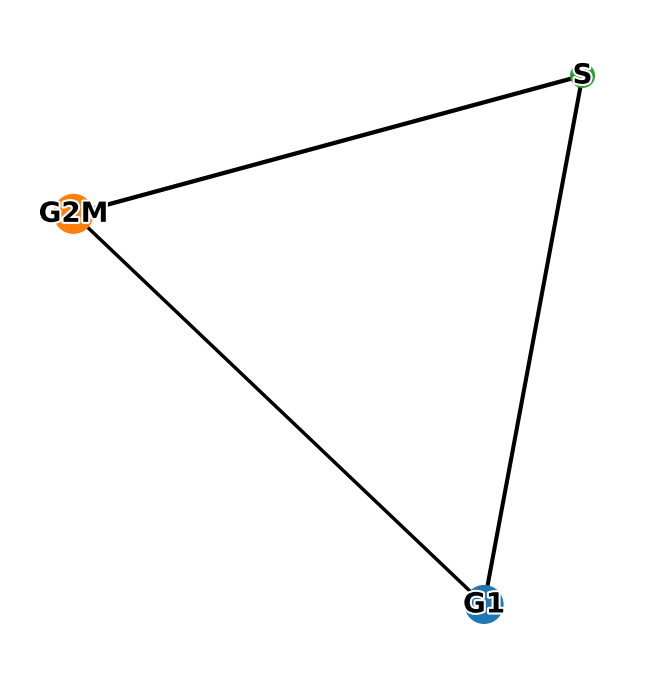

init_pos.shape=(6960, 2) type(init_pos)=<class 'numpy.ndarray'>
data.shape=(6960, 20) type(data)=<class 'cupy.ndarray'>
graph.shape=(6960, 6960) type(graph)=<class 'scipy.sparse._csr.csr_matrix'>
min_dist=0.02 spread=0.55 a=np.float64(4.840879466679525) b=np.float64(0.8278022523436259)
embedding.shape=(6960, 2) type(embedding)=<class 'cupy.ndarray'>


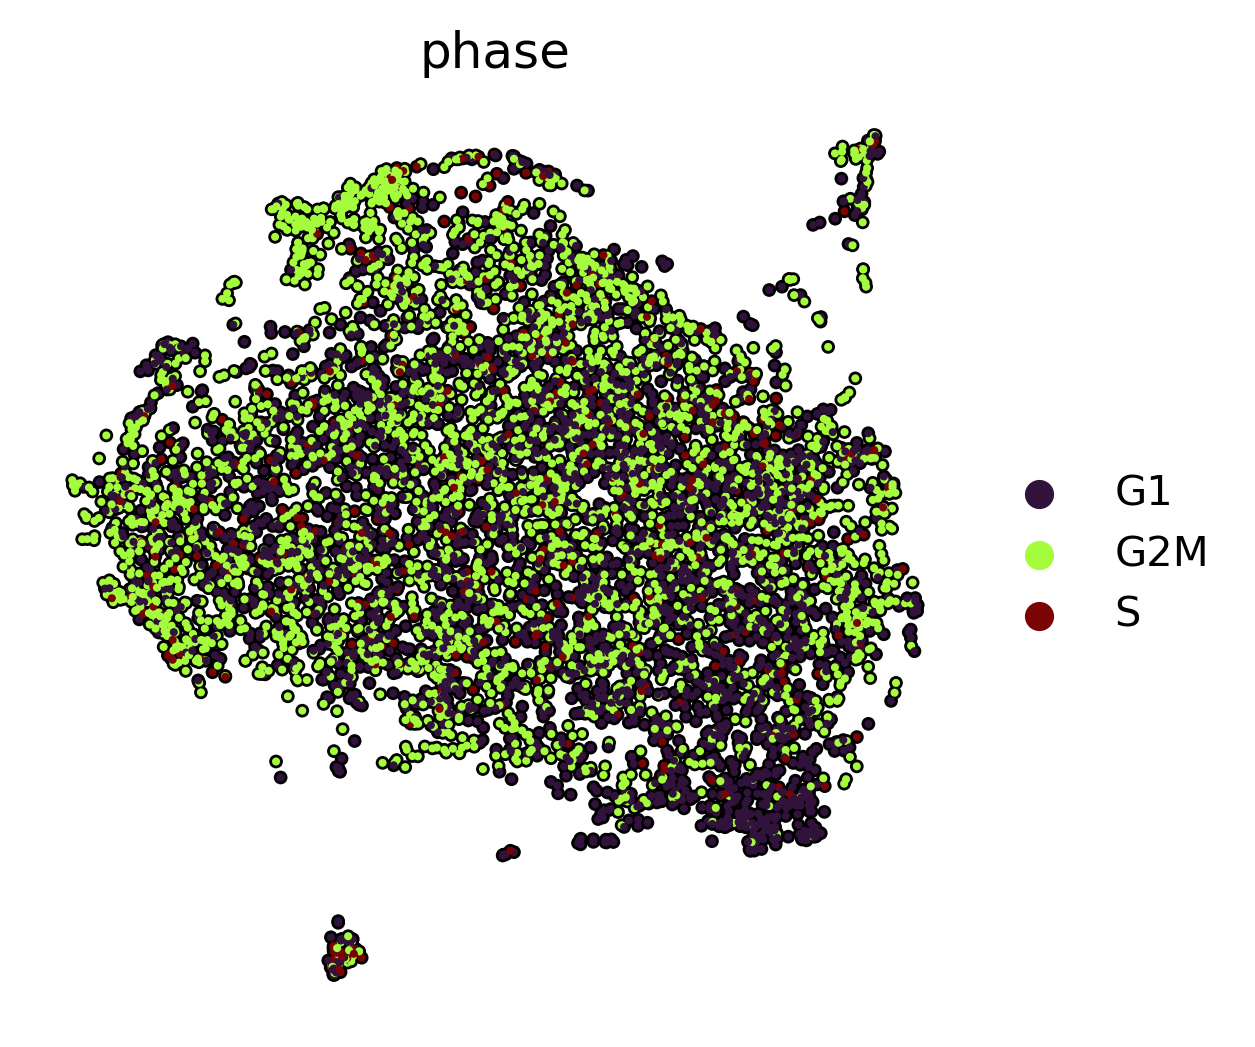

CPU times: user 744 ms, sys: 63.6 ms, total: 807 ms
Wall time: 845 ms


In [39]:
%%time 

n_neighbors = 7
paga_group_column = "phase"
n_pcs = 10
min_dist = 0.02
spread = 0.55
leiden_resolution = 0.65
colormap = 'turbo'

"""
PAGA
"""
embed = model.get_latent_representation()
embed = sc.AnnData(embed, obs=adata.obs)

rsc.get.anndata_to_GPU(embed)
rsc.pp.pca(embed)

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 2
sc.pl.pca_variance_ratio(embed)
rsc.pp.neighbors(
    embed, 
    n_pcs=n_pcs, 
    n_neighbors=n_neighbors,
)

# plot the embedding
sc.tl.paga(embed, groups=paga_group_column)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4
sc.pl.paga(
    embed, 
    fontoutline=1.5, 
    edge_width_scale=0.25,  
    frameon=False,          
)

embed.obsm['X_paga'] = get_init_pos_from_paga(embed)

"""
UMAP
"""
# get the inputs
init_pos = embed.obsm['X_paga'].copy()
data = embed.X.copy()
graph = embed.obsp['connectivities'].copy()

print(f"{init_pos.shape=} {type(init_pos)=}")
print(f"{data.shape=} {type(data)=}")
print(f"{graph.shape=} {type(graph)=}")

# find params
a, b = find_ab_params(spread=spread, min_dist=min_dist)
print(f"{min_dist=} {spread=} {a=} {b=}")

# use simplicial_set_embedding
embedding = simplicial_set_embedding(
    data=data,
    graph=graph,
    a=a, b=b,
    n_components=2,
    init=init_pos,
    random_state=1729,
)

# store embedding
print(f"{embedding.shape=} {type(embedding)=}")
embed.obsm['X_umap'] = embedding.get().copy()

rsc.tl.leiden(embed, resolution=leiden_resolution)

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    embed, 
    color='phase', 
    size=15,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    palette=colormap,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
)

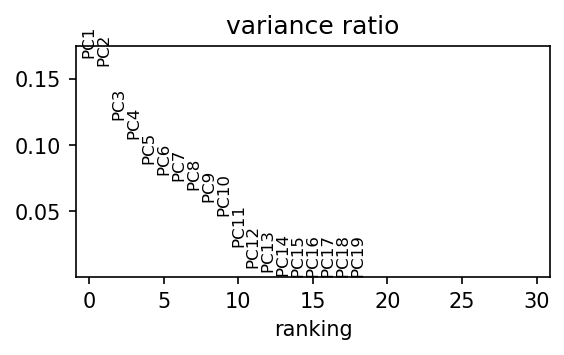

CPU times: user 270 ms, sys: 26.8 ms, total: 297 ms
Wall time: 305 ms


In [26]:
%%time 

embed = model.get_latent_representation()
embed = sc.AnnData(embed, obs=adata.obs)

rsc.get.anndata_to_GPU(embed)

rsc.pp.pca(embed)

rsc.get.anndata_to_CPU(embed)

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 2
sc.pl.pca_variance_ratio(embed)

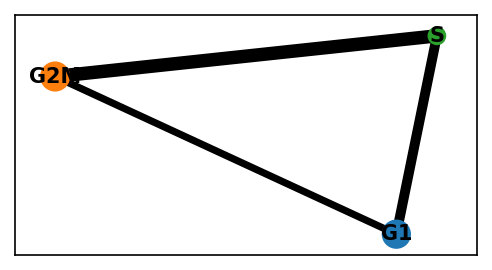

In [29]:

sc.tl.paga(
    embed,
    groups='phase',
)


sc.pl.paga(embed)

/home/jrcwycy/miniconda3/envs/rapids_singlecell/lib/python3.13/site-packages/umap/umap_.py:1401: RuntimeWarning: divide by zero encountered in power
  return 1.0 / (1.0 + a * x ** (2 * b))


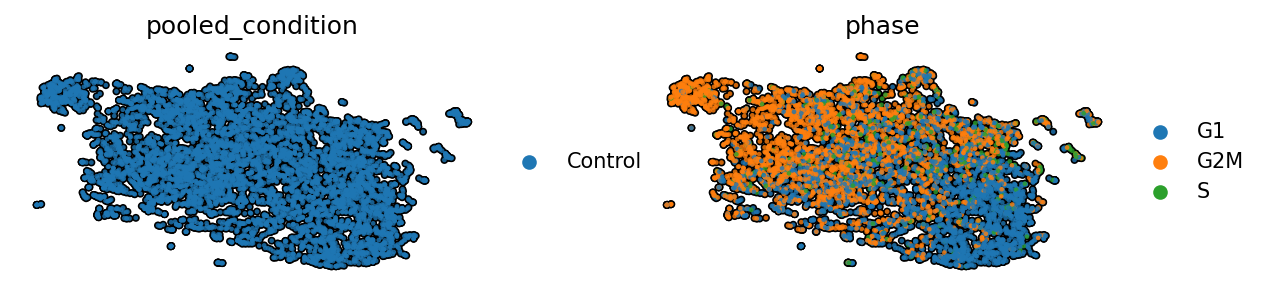

In [30]:
rsc.get.anndata_to_GPU(embed)

rsc.pp.neighbors(
    embed,
    n_neighbors=5,
)

rsc.get.anndata_to_CPU(embed)

sc.tl.umap(
    embed,
    init_pos='paga',
    min_dist=0.01,
    spread=5,
)



sc.pl.umap(
    embed,
    color=['pooled_condition', 'phase'],
    size=20,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False, 
    alpha=0.8,
)

In [14]:
%%time 

bdata.obsm["X_scVI"] = model.get_latent_representation()

bdata.layers['scvi'] = model.get_normalized_expression()

bdata

CPU times: user 813 ms, sys: 383 ms, total: 1.2 s
Wall time: 1.21 s


AnnData object with n_obs × n_vars = 6960 × 15393
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'leiden', 'cluster_str', 'S_score', 'G2M_score', 'phase', '_scvi_batch', '_scvi_labels'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'di

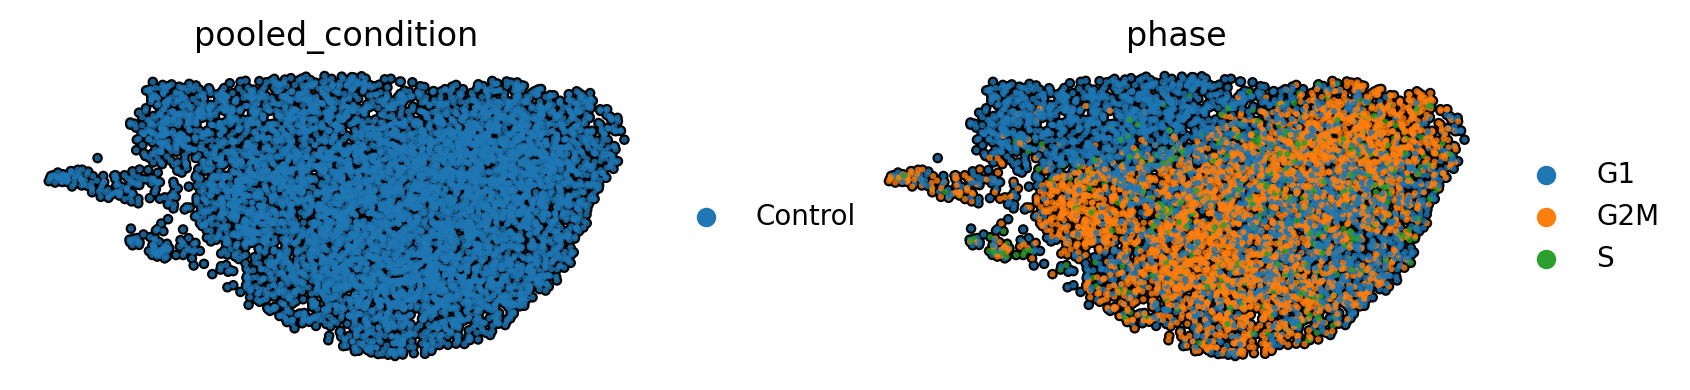

In [15]:
rsc.get.anndata_to_GPU(bdata)

rsc.pp.neighbors(
    bdata,
    use_rep='X_scVI',
)

rsc.tl.umap(bdata)

rsc.get.anndata_to_CPU(bdata)

sc.pl.umap(
    bdata,
    color=['pooled_condition', 'phase'],
    size=20,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False, 
    alpha=0.8,
)

39
34


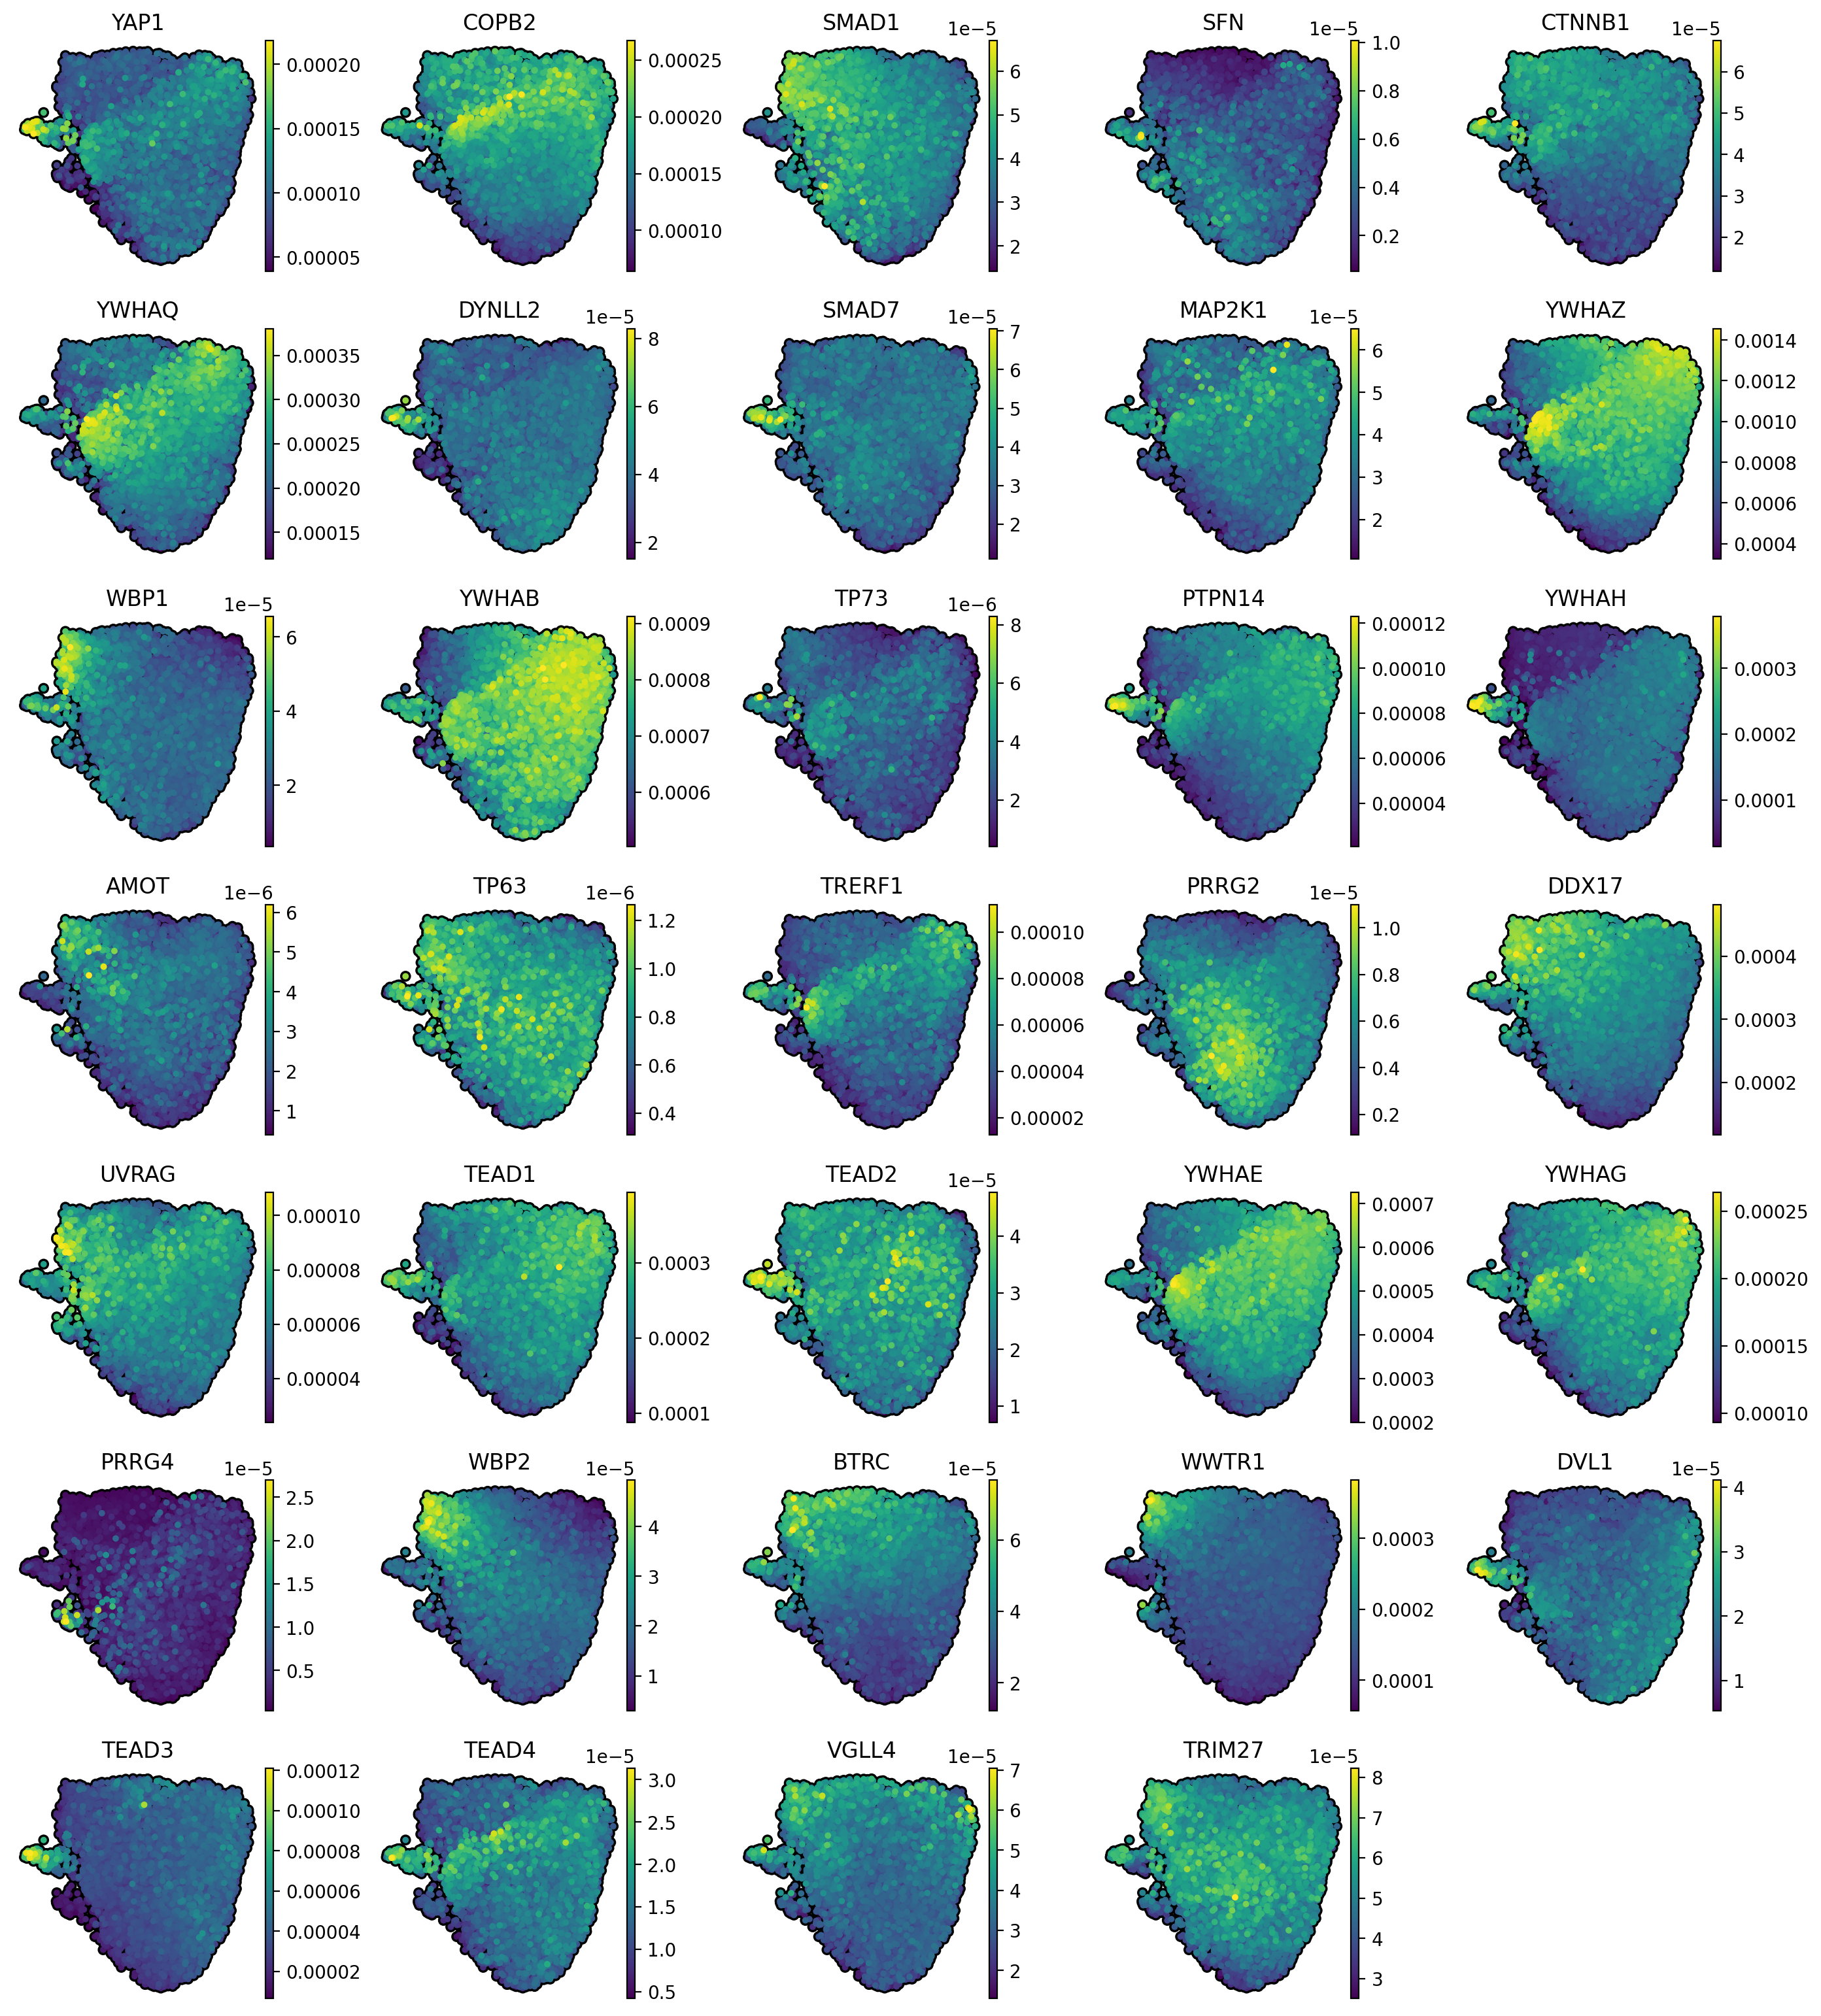

In [16]:
genes_to_plot = [
    'YAP1', 'COPB2', 'SMAD1', 'SFN', 'CTNNB1', 'SLC9A3R1', 'YWHAQ', 'DYNLL2', 'SMAD7', 'MAP2K1', 'YWHAZ', 'WBP1', 'YWHAB', 'TP73', 'PTPN14', 'YWHAH',
    'AMOT', 'TP63', 'TRERF1', 'PRRG2', 'DDX17', 'UVRAG', 'LATS1', 'TEAD1', 'TEAD2', 'YWHAE', 'SLC9A3R2', 'YWHAG', 'PRRG4', 'WBP2', 'BTRC',
    'WWTR1', 'DVL1', 'TEAD3', 'VGLL1', 'TEAD4', 'VGLL4', 'TRIM27', 'KRT40',
]
print(len(genes_to_plot))

genes_to_plot = [gene for gene in genes_to_plot if gene in bdata.var_names]
print(len(genes_to_plot))

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 2.5, 2.5

sc.pl.umap(
    bdata,
    color=genes_to_plot,
    size=50,
    ncols=5,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False, 
    alpha=1,
    layer='scvi',
)

In [18]:
bdata

AnnData object with n_obs × n_vars = 6960 × 15393
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'leiden', 'cluster_str', 'S_score', 'G2M_score', 'phase', '_scvi_batch', '_scvi_labels'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'di

# embedding